<a href="https://colab.research.google.com/github/ywchanna2001/Protein_Conformational_Ensembles_Prediction/blob/dev/modules/MSA-Generation/MSA-Generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#@title Input protein sequence(s)
from google.colab import files
import os
import re
import hashlib
import random

from sys import version_info
python_version = f"{version_info.major}.{version_info.minor}"

def add_hash(x,y):
  return x+"_"+hashlib.sha1(y.encode()).hexdigest()[:5]

query_sequence = 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGG' #@param {type:"string"}
#@markdown  - Use `:` to specify inter-protein chainbreaks for **modeling complexes** (supports homo- and hetro-oligomers). For example **PI...SK:PI...SK** for a homodimer
jobname = 'Test1' #@param {type:"string"}
# number of models to use
num_relax = 5 #@param [0, 1, 5] {type:"raw"}
#@markdown - specify how many of the top ranked structures to relax using amber
template_mode = "none" #@param ["none", "pdb100","custom"]
#@markdown - `none` = no template information is used. `pdb100` = detect templates in pdb100 (see [notes](#pdb100)). `custom` - upload and search own templates (PDB or mmCIF format, see [notes](#custom_templates))

use_amber = num_relax > 0

# remove whitespaces
query_sequence = "".join(query_sequence.split())

basejobname = "".join(jobname.split())
basejobname = re.sub(r'\W+', '', basejobname)
jobname = add_hash(basejobname, query_sequence)

# check if directory with jobname exists
def check(folder):
  if os.path.exists(folder):
    return False
  else:
    return True
if not check(jobname):
  n = 0
  while not check(f"{jobname}_{n}"): n += 1
  jobname = f"{jobname}_{n}"

# make directory to save results
os.makedirs(jobname, exist_ok=True)

# save queries
queries_path = os.path.join(jobname, f"{jobname}.csv")
with open(queries_path, "w") as text_file:
  text_file.write(f"id,sequence\n{jobname},{query_sequence}")

if template_mode == "pdb100":
  use_templates = True
  custom_template_path = None
elif template_mode == "custom":
  custom_template_path = os.path.join(jobname,f"template")
  os.makedirs(custom_template_path, exist_ok=True)
  uploaded = files.upload()
  use_templates = True
  for fn in uploaded.keys():
    os.rename(fn,os.path.join(custom_template_path,fn))
else:
  custom_template_path = None
  use_templates = False

print("jobname",jobname)
print("sequence",query_sequence)
print("length",len(query_sequence.replace(":","")))

jobname Test1_7686d_0
sequence MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGG
length 76


In [2]:
#@title Install dependencies
%%time
import os
USE_AMBER = use_amber
USE_TEMPLATES = use_templates
PYTHON_VERSION = python_version

if not os.path.isfile("COLABFOLD_READY"):
  print("installing colabfold...")
  os.system("pip install -q --no-warn-conflicts 'colabfold[alphafold-minus-jax] @ git+https://github.com/sokrypton/ColabFold'")
  if os.environ.get('TPU_NAME', False) != False:
    os.system("pip uninstall -y jax jaxlib")
    os.system("pip install --no-warn-conflicts --upgrade dm-haiku==0.0.10 'jax[cuda12_pip]'==0.3.25 -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/colabfold colabfold")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/alphafold alphafold")
  # hack to fix TF crash
  os.system("rm -f /usr/local/lib/python3.*/dist-packages/tensorflow/core/kernels/libtfkernel_sobol_op.so")
  os.system("touch COLABFOLD_READY")

if USE_AMBER or USE_TEMPLATES:
  if not os.path.isfile("CONDA_READY"):
    print("installing conda...")
    os.system("wget -qnc https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh")
    os.system("bash Miniforge3-Linux-x86_64.sh -bfp /usr/local")
    os.system("mamba config --set auto_update_conda false")
    os.system("touch CONDA_READY")

if USE_TEMPLATES and not os.path.isfile("HH_READY") and USE_AMBER and not os.path.isfile("AMBER_READY"):
  print("installing hhsuite and amber...")
  os.system(f"mamba install -y -c conda-forge -c bioconda kalign2=2.04 hhsuite=3.3.0 openmm=8.2.0 python='{PYTHON_VERSION}' pdbfixer")
  os.system("touch HH_READY")
  os.system("touch AMBER_READY")
else:
  if USE_TEMPLATES and not os.path.isfile("HH_READY"):
    print("installing hhsuite...")
    os.system(f"mamba install -y -c conda-forge -c bioconda kalign2=2.04 hhsuite=3.3.0 python='{PYTHON_VERSION}'")
    os.system("touch HH_READY")
  if USE_AMBER and not os.path.isfile("AMBER_READY"):
    print("installing amber...")
    os.system(f"mamba install -y -c conda-forge openmm=8.2.0 python='{PYTHON_VERSION}' pdbfixer")
    os.system("touch AMBER_READY")

CPU times: user 58 µs, sys: 0 ns, total: 58 µs
Wall time: 63.2 µs


In [3]:
#@markdown ### MSA options (custom MSA upload, single sequence, pairing mode)
msa_mode = "mmseqs2_uniref_env" #@param ["mmseqs2_uniref_env", "mmseqs2_uniref","single_sequence","custom"]
pair_mode = "unpaired_paired" #@param ["unpaired_paired","paired","unpaired"] {type:"string"}
#@markdown - "unpaired_paired" = pair sequences from same species + unpaired MSA, "unpaired" = seperate MSA for each chain, "paired" - only use paired sequences.

# decide which a3m to use
if "mmseqs2" in msa_mode:
  a3m_file = os.path.join(jobname,f"{jobname}.a3m")

elif msa_mode == "custom":
  a3m_file = os.path.join(jobname,f"{jobname}.custom.a3m")
  if not os.path.isfile(a3m_file):
    custom_msa_dict = files.upload()
    custom_msa = list(custom_msa_dict.keys())[0]
    header = 0
    import fileinput
    for line in fileinput.FileInput(custom_msa,inplace=1):
      if line.startswith(">"):
         header = header + 1
      if not line.rstrip():
        continue
      if line.startswith(">") == False and header == 1:
         query_sequence = line.rstrip()
      print(line, end='')

    os.rename(custom_msa, a3m_file)
    queries_path=a3m_file
    print(f"moving {custom_msa} to {a3m_file}")

else:
  a3m_file = os.path.join(jobname,f"{jobname}.single_sequence.a3m")
  with open(a3m_file, "w") as text_file:
    text_file.write(">1\n%s" % query_sequence)

In [8]:
# --- MODULE 1: ROBUST MSA GENERATION (Fixed) ---
import os
import time
from colabfold.colabfold import run_mmseqs2

search_mode = "mmseqs2_uniref_env"
use_env = "env" in search_mode

print(f"Target Sequence: {query_sequence[:30]}...")
print(f"Job Name: {jobname}")

# ✅ FIX 1: Delete any stale cached .a3m file so the API is actually called
a3m_cache = os.path.join(jobname, f"{jobname}.a3m")
if os.path.isfile(a3m_cache):
    os.remove(a3m_cache)
    print("Removed cached .a3m — forcing fresh API search...")

print("Status: Contacting MMseqs2 server (this can take 1–3 minutes)...")

try:
    # ✅ FIX 2: Capture result correctly — run_mmseqs2 returns a LIST of a3m content strings
    result = run_mmseqs2(
        x=query_sequence,
        prefix=jobname,
        use_env=use_env,
        use_filter=True,           # ✅ FIX 3: Required for proper hit filtering
        use_pairing=False,
    )

    # ✅ FIX 4: Flatten the result into individual lines correctly
    # result is a list of strings; each string can be a full a3m block
    if isinstance(result, list):
        a3m_lines = "\n".join(result).splitlines(keepends=True)
    else:
        a3m_lines = result.splitlines(keepends=True)

    # ✅ FIX 5: Count sequences properly (lines starting with '>')
    num_seqs = sum(1 for line in a3m_lines if line.startswith(">"))

    print(f"Total lines in result: {len(a3m_lines)}")
    print(f"Sequences found (headers): {num_seqs}")

    if num_seqs <= 1:
        print("❌ ERROR: Server returned 0 hits.")
        print("Debugging info:")
        print("".join(a3m_lines[:10]))  # Show first 10 lines for diagnosis
        print("\nPossible causes:")
        print("  - MMseqs2 API server is down or overloaded (try again in 1 min)")
        print("  - Sequence too short/non-standard for database hits")
        print("  - Network issue in Colab (try Runtime > Restart and run all)")
    else:
        # Save valid MSA
        msa_module_dir = "research_msa_output"
        os.makedirs(msa_module_dir, exist_ok=True)
        msa_file_path = os.path.join(msa_module_dir, f"{jobname}.a3m")

        with open(msa_file_path, "w") as f:
            f.writelines(a3m_lines)

        print(f"✅ SUCCESS: {num_seqs} sequences saved to {msa_file_path}")

except Exception as e:
    print(f"❌ SERVER ERROR: {e}")
    import traceback
    traceback.print_exc()

Target Sequence: MQIFVKTLTGKTITLEVEPSDTIENVKAKI...
Job Name: Test1_7686d_0
Status: Contacting MMseqs2 server (this can take 1–3 minutes)...


COMPLETE: 100%|██████████| 150/150 [elapsed: 00:02 remaining: 00:00]

Total lines in result: 43154
Sequences found (headers): 21577
✅ SUCCESS: 21577 sequences saved to research_msa_output/Test1_7686d_0.a3m


Generating plot for 21577 sequences...


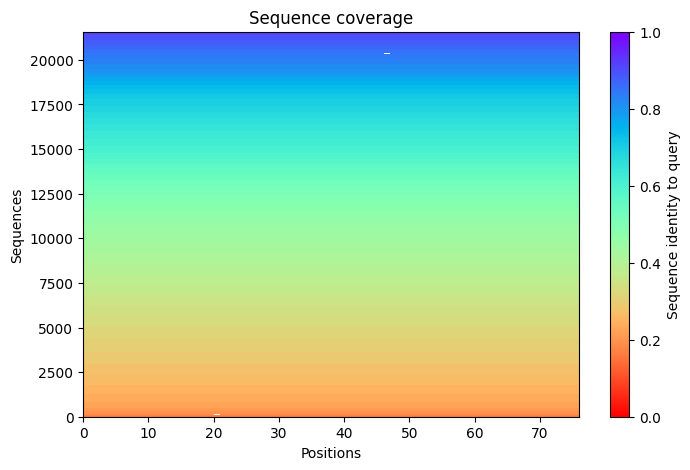

In [9]:
#@title Module 1 Visualization: MSA Coverage Plot (Final Fix)
import matplotlib.pyplot as plt
import numpy as np
import os
from colabfold.plot import plot_msa_v2

if 'a3m_lines' in locals():
    full_msa_text = "".join(a3m_lines)
    lines = full_msa_text.splitlines()

    processed_seqs = []
    for line in lines:
        line = line.strip()
        if not line or line.startswith(">") or line.startswith("#"):
            continue
        # Remove lowercase (insertions)
        clean_seq = "".join([c for c in line if not c.islower()])
        if clean_seq:
            processed_seqs.append(clean_seq)

    if len(processed_seqs) <= 1:
        print("⚠️ WARNING: Only 1 sequence found (the query).")
        print("DBSCAN clustering (Module 2) requires multiple sequences.")
        print("Verify your 'msa_mode' is set to 'mmseqs2_uniref_env' and the server is responding.")
        # Debug: Print first few characters of raw data
        print(f"Raw data start: {full_msa_text[:100]}...")

    # 1. Prepare Numerical Matrix
    map_str = "ARNDCQEGHILKMFPSTWYV-"
    res_map = {res: i for i, res in enumerate(map_str)}
    msa_indices = []
    for seq in processed_seqs:
        msa_indices.append([res_map.get(res.upper(), 21) for res in seq])

    msa_arr = np.array(msa_indices)

    # 2. Fix 'num_alignments' and other required keys for the plotter
    # This prevents the 'num_alignments' KeyError
    num_res = msa_arr.shape[1]
    feature_dict = {
        "msa": msa_arr,
        "num_alignments": np.array([len(processed_seqs)] * num_res) # Required key
    }

    # 3. Generate Plot
    try:
        print(f"Generating plot for {len(processed_seqs)} sequences...")
        fig = plot_msa_v2(feature_dict)
        plt.show()
    except Exception as e:
        print(f"Detailed Plotting Error: {e}")
        # Fallback: Simple plot if ColabFold's internal plotter fails
        plt.figure(figsize=(10, 3))
        plt.imshow(msa_arr, aspect='auto', cmap='viridis')
        plt.title(f"MSA Matrix (Rows: {msa_arr.shape[0]}, Cols: {msa_arr.shape[1]})")
        plt.xlabel("Residue Position")
        plt.ylabel("Sequence Index")
        plt.show()

else:
    print("Error: 'a3m_lines' not found.")